In [1]:
from mfg import MFG_config, MFG

In [ ]:
# ── Simulation grid ──────────────────────────────────────────────────────────
T   = 1       # time horizon (Section 6)
Ndt = 1000    # time steps  → dt = 0.001

# ── Major bank parameters (Fig B.5, Fig B.6) ─────────────────────────────────
G        = 0.5   # relative market size of major bank  (F = 1-G = 0.5)
a        = 5     # minor bank mean-reversion rate (Section 6.2 baseline)
a_0      = a * G # = 2.5  market-clearing condition (eq 2.8): a_0 = a*G
sigma_0  = 1.0   # major bank reserve volatility
q_0      = 1.0   # major bank incentive to trade with central bank  (Fig B.5)
epslon_0 = 10.0  # major bank running penalty on reserve deviation  (Fig B.6)
c_0      = 0.0   # major bank terminal penalty                       (Fig B.6)

# ── Minor bank parameters (Fig B.5) ──────────────────────────────────────────
sigma    = 1.0   # minor bank reserve volatility
q        = 1.0   # minor bank incentive to trade with central bank
epslon   = 1.5   # minor bank running penalty  (must satisfy q^2 <= epslon)
c        = 0.0   # minor bank terminal penalty

# ── Monte Carlo ───────────────────────────────────────────────────────────────
N     = 700      # number of minor banks (Section 6)
N_sim = 300  # Monte Carlo paths     (Section 6)

config = MFG_config(
    T=T, Ndt=Ndt,
    a_0=a_0, sigma_0=sigma_0, c_0=c_0, epslon_0=epslon_0, q_0=q_0,
    a=a,     sigma=sigma,     c=c,     epslon=epslon,       q=q,
    G=G,
)
print(config)

MFG_config: {'T': 1, 'Ndt': 1000, 'dt': 0.001, 'a_0': 2.5, 'sigma_0': 1.0, 'c_0': 0.0, 'epslon_0': 10.0, 'q_0': 1.0, 'a': 5, 'sigma': 1.0, 'c': 0.0, 'epslon': 1.5, 'q': 1.0, 'G': 0.5, 'F': 0.5}


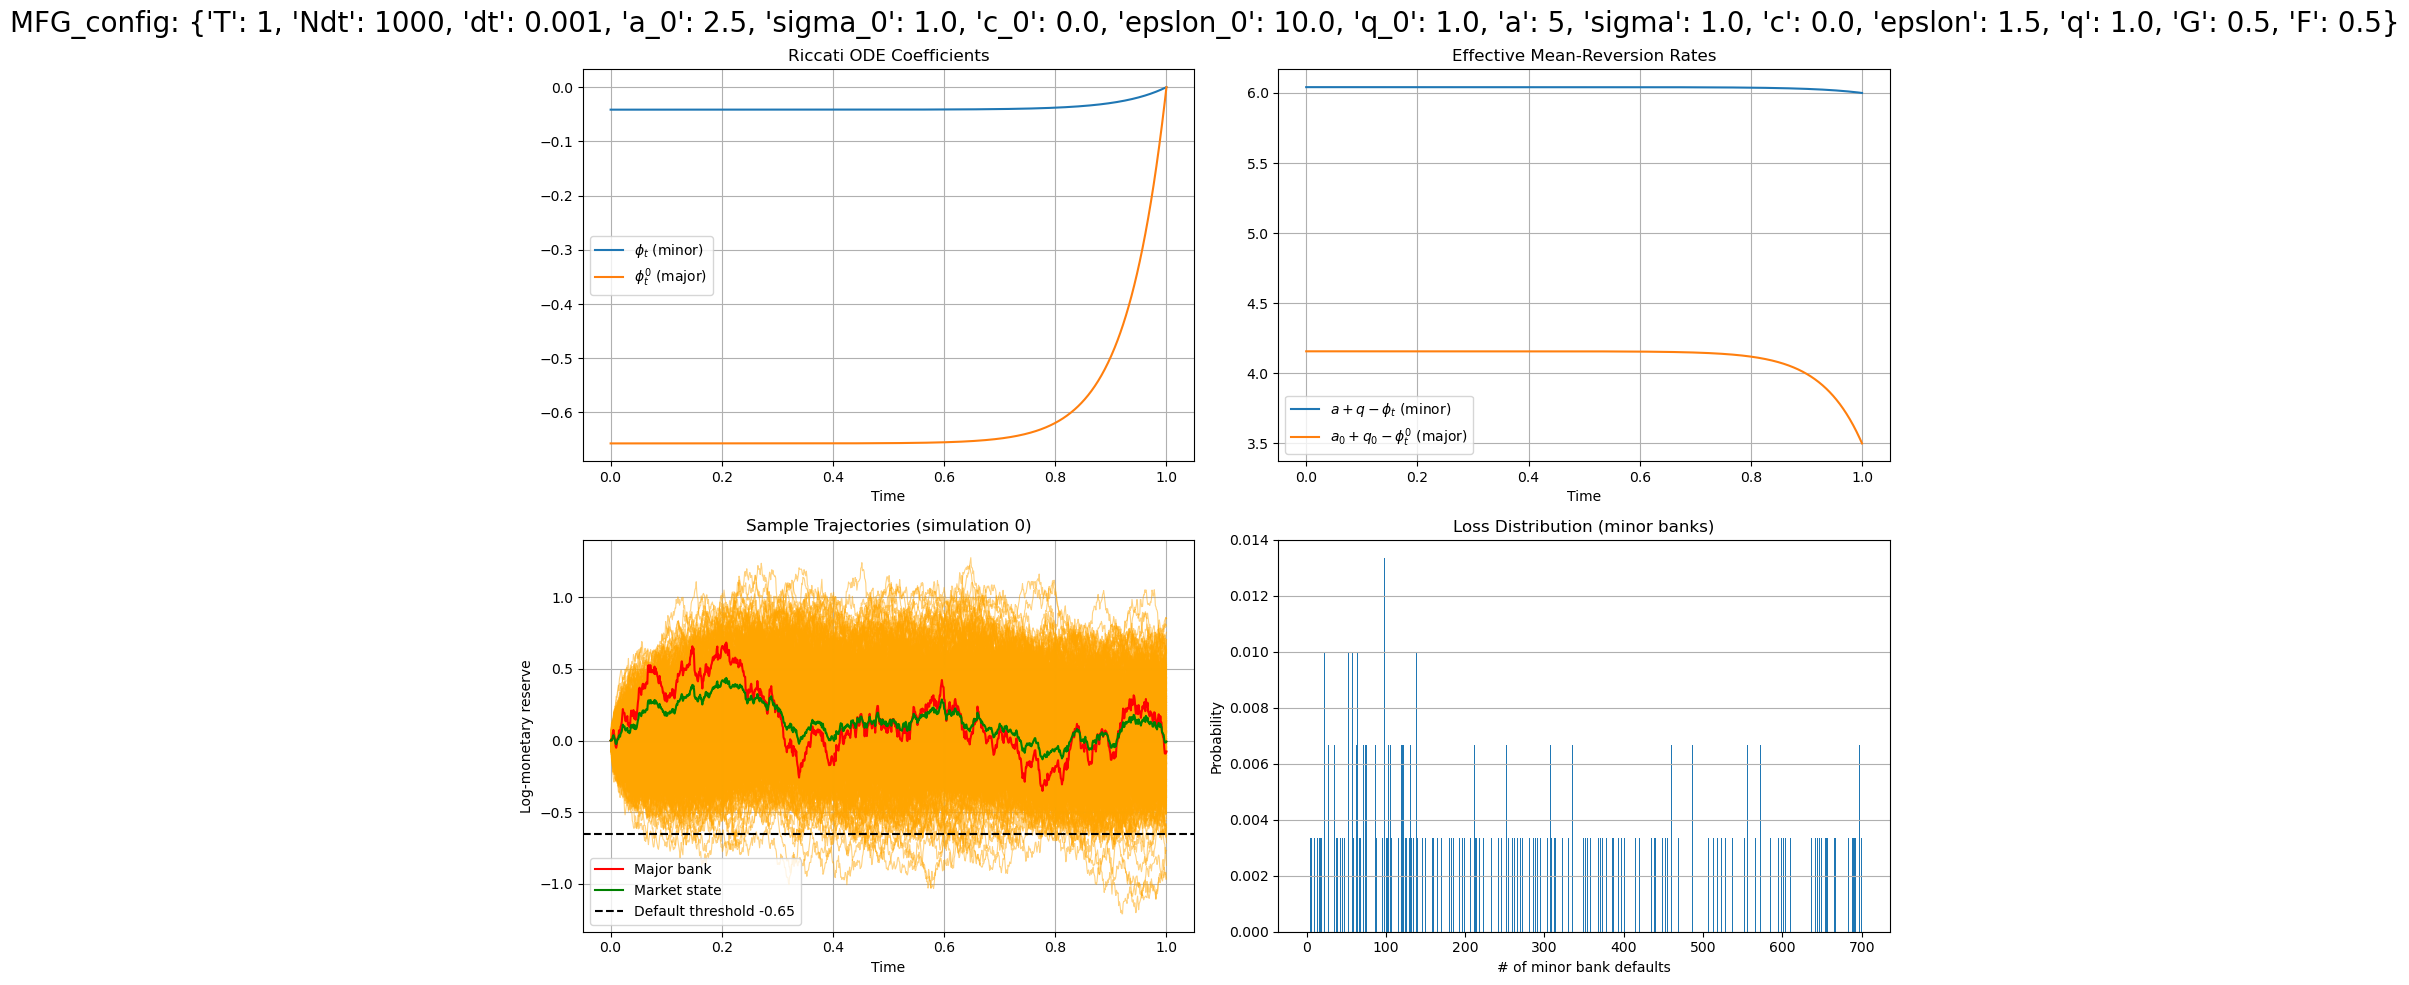

(array([[ 0.00000000e+00,  0.00000000e+00,  3.07073638e-05, ...,
          6.32662986e-02,  6.28017175e-02,  6.23446844e-02],
        [ 0.00000000e+00,  0.00000000e+00, -3.62415225e-05, ...,
         -1.04564127e-01, -1.05280285e-01, -1.05935740e-01],
        [ 0.00000000e+00,  0.00000000e+00, -9.58582886e-05, ...,
          2.04129064e-01,  2.02512898e-01,  2.00865105e-01],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  2.02911320e-05, ...,
          5.70343945e-02,  5.67450606e-02,  5.64443016e-02],
        [ 0.00000000e+00,  0.00000000e+00,  2.03798320e-05, ...,
          1.34239078e-01,  1.33247740e-01,  1.32450677e-01],
        [ 0.00000000e+00,  0.00000000e+00,  3.08002178e-05, ...,
          3.72644414e-01,  3.72476790e-01,  3.72343930e-01]]),
 array([[ 0.        ,  0.01016544,  0.00125114, ..., -0.09156843,
         -0.08952995, -0.07623852],
        [ 0.        , -0.01199748, -0.01782235, ..., -0.3432439 ,
         -0.32374689, -0.2775584 ],
        [ 0.        , -0.

In [3]:
model = MFG(config)
model.solve_ODE()        # backward Euler for phi_t and phi_0_t
model.simulate(N, N_sim) 

---
## Comparison Study — Trajectory Plots
One parameter varied at a time. Each subplot shows 10 sampled minor banks (orange), major bank (red), market state (green), default threshold D (black dashed). Same `np.random.seed(42)` across subplots for a fair comparison.

In [9]:
import importlib, mfg as mfg_module
importlib.reload(mfg_module)
import numpy as np, matplotlib.pyplot as plt

D       = -0.65
t_grid  = np.linspace(0, T, Ndt + 1)
sim_idx = 0          # which Monte Carlo path to display
n_show  = min(N, 300) # how many minor bank trajectories to draw
colors  = plt.cm.tab10.colors

def make_config(G_val=None, a_val=None, q_val=None):
    _G = G_val if G_val is not None else G
    _a = a_val if a_val is not None else a
    _q = q_val if q_val is not None else q
    return MFG_config(
        T=T, Ndt=Ndt,
        a_0=_a * _G,  sigma_0=sigma_0, c_0=c_0,
        epslon_0=epslon_0, q_0=_q,
        a=_a, sigma=sigma, c=c,
        epslon=max(_q**2 + 0.5, epslon),
        q=_q, G=_G,
    )

def traj_plot(ax, x_bar, x_major, x_minor, m, label):
    for b in np.linspace(0, x_minor.shape[1] - 1, n_show, dtype=int):
        ax.plot(t_grid, x_minor[sim_idx, b, :], color='orange', alpha=0.4, linewidth=0.7)
    market_state = m.F * x_bar[sim_idx] + m.G * x_major[sim_idx]
    ax.plot(t_grid, x_major[sim_idx], color='red',   linewidth=1.5, label='Major')
    ax.plot(t_grid, market_state,      color='green', linewidth=1.5, label='Market state')
    ax.axhline(D, color='black', linestyle='--', linewidth=1, label=f'D={D}')
    ax.set_title(label); ax.set_xlabel('Time'); ax.grid(True, alpha=0.3)

def ode_plot(models, labels, title):
    # ── Figure 1: Minor bank ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Minor Bank ODE — {title}', fontsize=11)
    for i, (m, lbl) in enumerate(zip(models, labels)):
        c = colors[i % 10]
        axes[0].plot(t_grid, m.phi,               color=c, label=lbl)
        axes[1].plot(t_grid, m.a + m.q - m.phi,  color=c, label=lbl)
    axes[0].set(xlabel='Time', ylabel=r'$\phi_t$',        title=r'$\phi_t$  (minor)')
    axes[1].set(xlabel='Time', ylabel=r'$a+q-\phi_t$',   title=r'Effective mean-reversion  $a+q-\phi_t$  (minor)')
    for ax in axes: ax.legend(fontsize=8); ax.grid(True)
    plt.tight_layout(); plt.show()

    # ── Figure 2: Major bank ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Major Bank ODE — {title}', fontsize=11)
    for i, (m, lbl) in enumerate(zip(models, labels)):
        c = colors[i % 10]
        axes[0].plot(t_grid, m.phi_0,                      color=c, label=lbl)
        axes[1].plot(t_grid, m.a_0 + m.q_0 - m.phi_0,    color=c, label=lbl)
    axes[0].set(xlabel='Time', ylabel=r'$\phi^0_t$',             title=r'$\phi^0_t$  (major)')
    axes[1].set(xlabel='Time', ylabel=r'$a_0+q_0-\phi^0_t$',   title=r'Effective mean-reversion  $a_0+q_0-\phi^0_t$  (major)')
    for ax in axes: ax.legend(fontsize=8); ax.grid(True)
    plt.tight_layout(); plt.show()

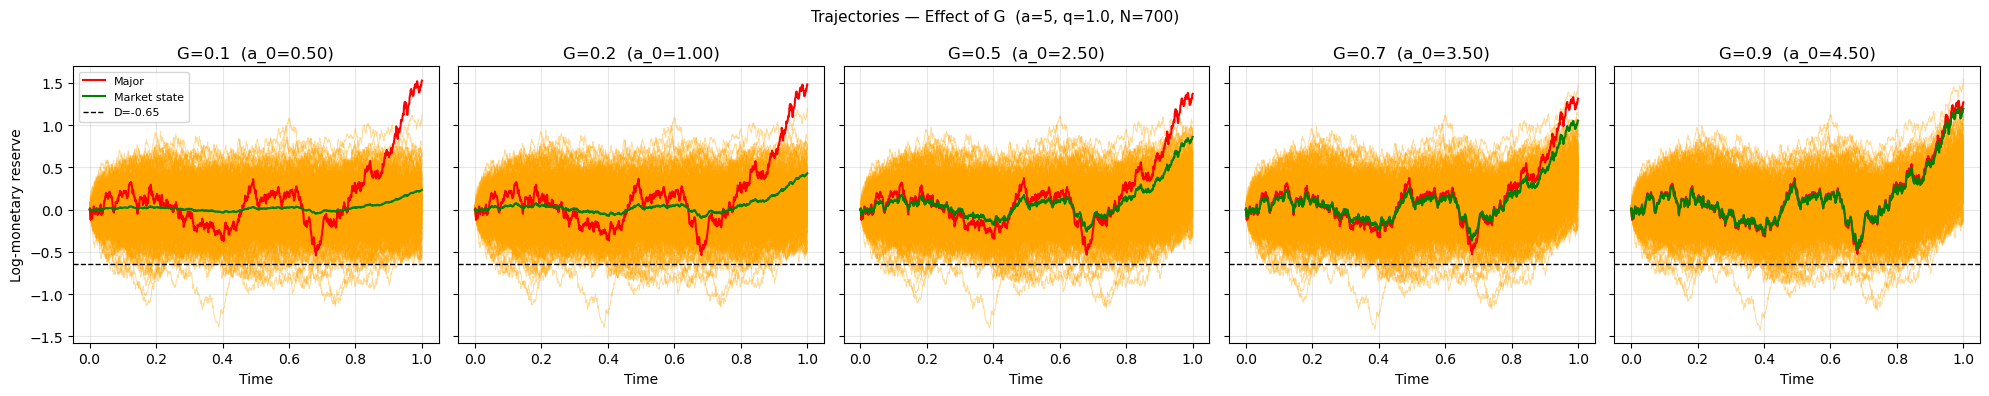

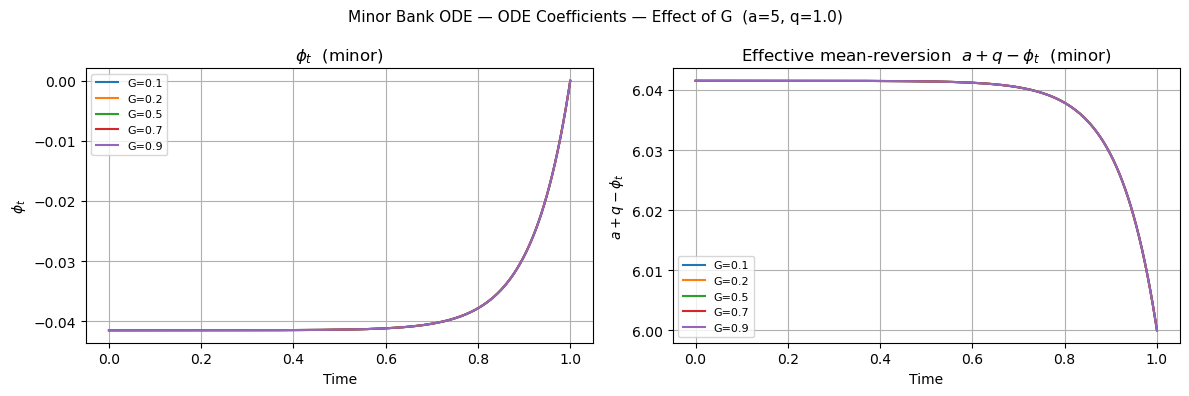

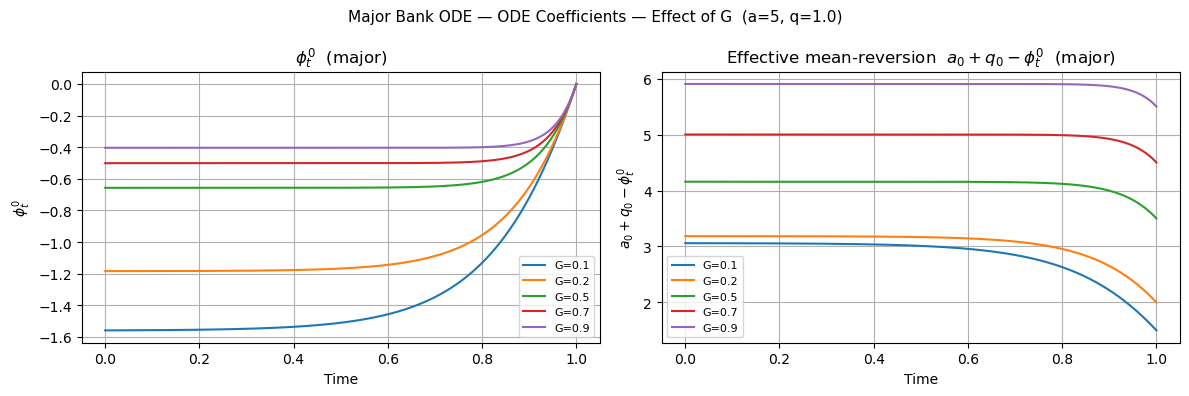

In [10]:
# ── G sweep: {0.1, 0.2, 0.5, 0.7, 0.9} ──────────────────────────────────────
G_sweep = [0.1, 0.2, 0.5, 0.7, 0.9]
labels  = [f'G={v}' for v in G_sweep]
models  = []

fig, axes = plt.subplots(1, len(G_sweep), figsize=(20, 4), sharey=True)
fig.suptitle(f'Trajectories — Effect of G  (a={a}, q={q}, N={N})', fontsize=11)
for ax, G_val, lbl in zip(axes, G_sweep, labels):
    np.random.seed(42)
    m = MFG(make_config(G_val=G_val)); m.solve_ODE()
    x_bar, x_major, x_minor = m.simulate(N, N_sim, do_plot=False)
    traj_plot(ax, x_bar, x_major, x_minor, m, f'{lbl}  (a_0={a*G_val:.2f})')
    models.append(m)
axes[0].set_ylabel('Log-monetary reserve'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

ode_plot(models, labels, f'ODE Coefficients — Effect of G  (a={a}, q={q})')

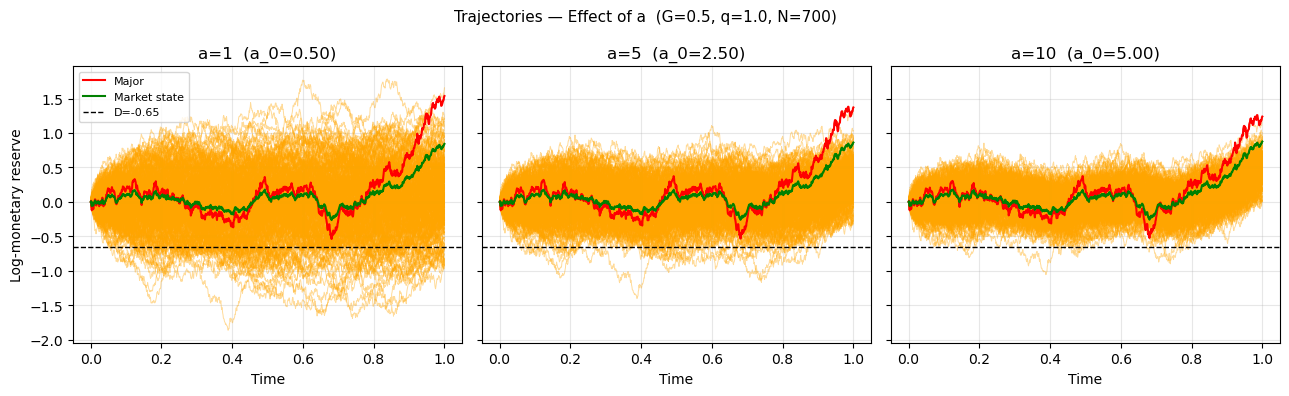

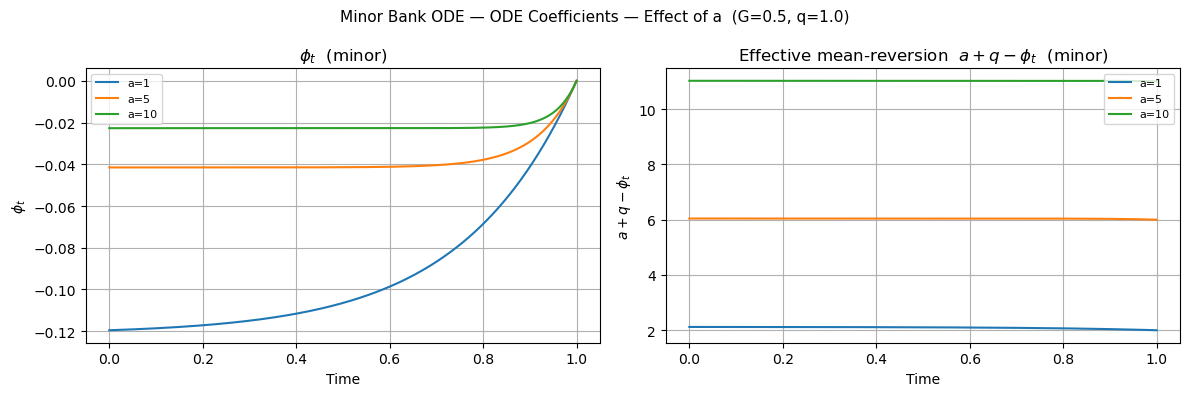

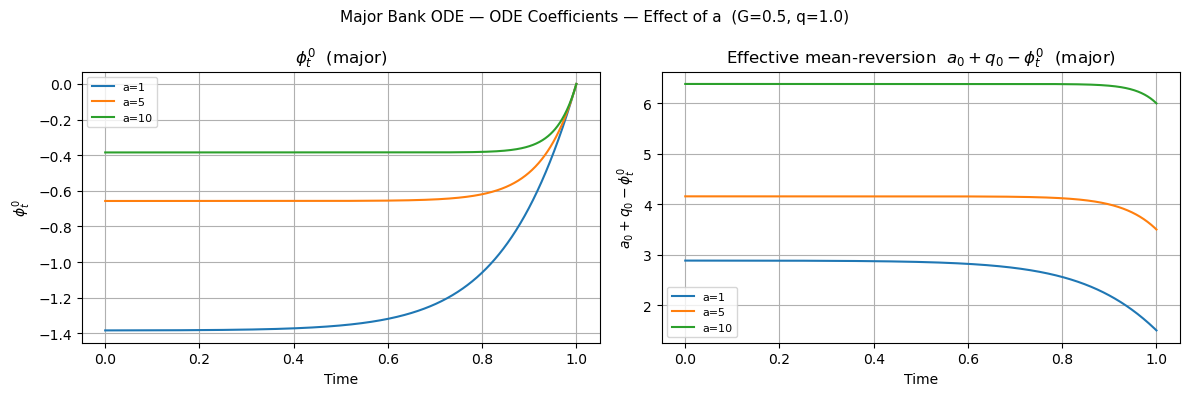

In [11]:
# ── a sweep: {1, 5, 10} ───────────────────────────────────────────────────────
a_sweep = [1, 5, 10]
labels  = [f'a={v}' for v in a_sweep]
models  = []

fig, axes = plt.subplots(1, len(a_sweep), figsize=(13, 4), sharey=True)
fig.suptitle(f'Trajectories — Effect of a  (G={G}, q={q}, N={N})', fontsize=11)
for ax, a_val, lbl in zip(axes, a_sweep, labels):
    np.random.seed(42)
    m = MFG(make_config(a_val=a_val)); m.solve_ODE()
    x_bar, x_major, x_minor = m.simulate(N, N_sim, do_plot=False)
    traj_plot(ax, x_bar, x_major, x_minor, m, f'{lbl}  (a_0={a_val*G:.2f})')
    models.append(m)
axes[0].set_ylabel('Log-monetary reserve'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

ode_plot(models, labels, f'ODE Coefficients — Effect of a  (G={G}, q={q})')

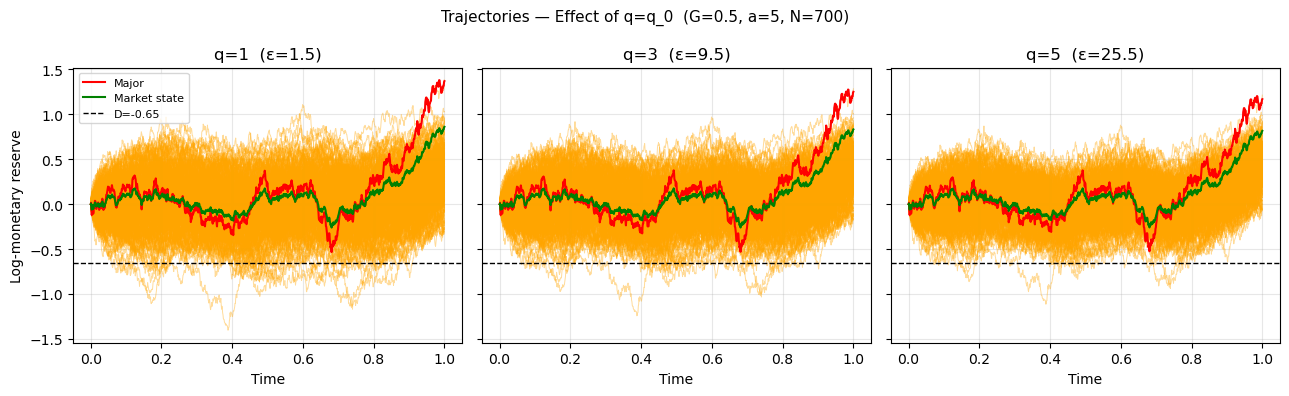

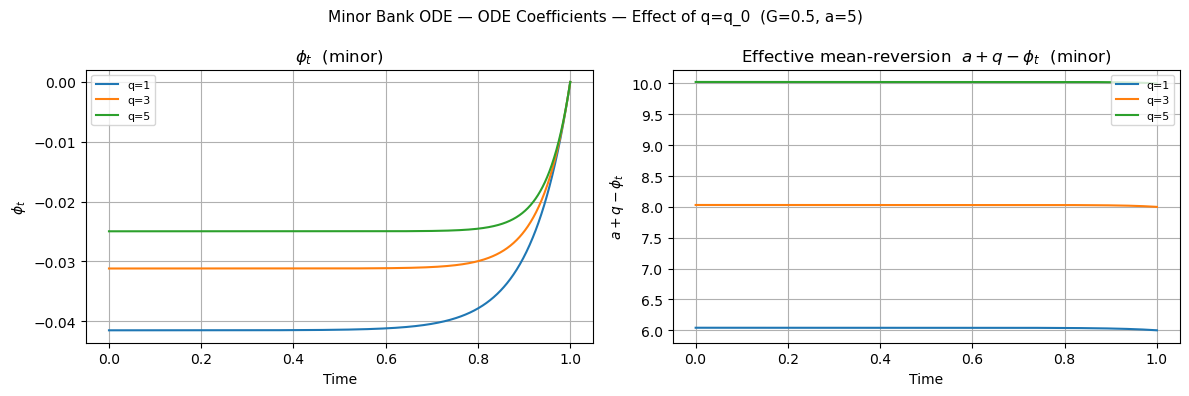

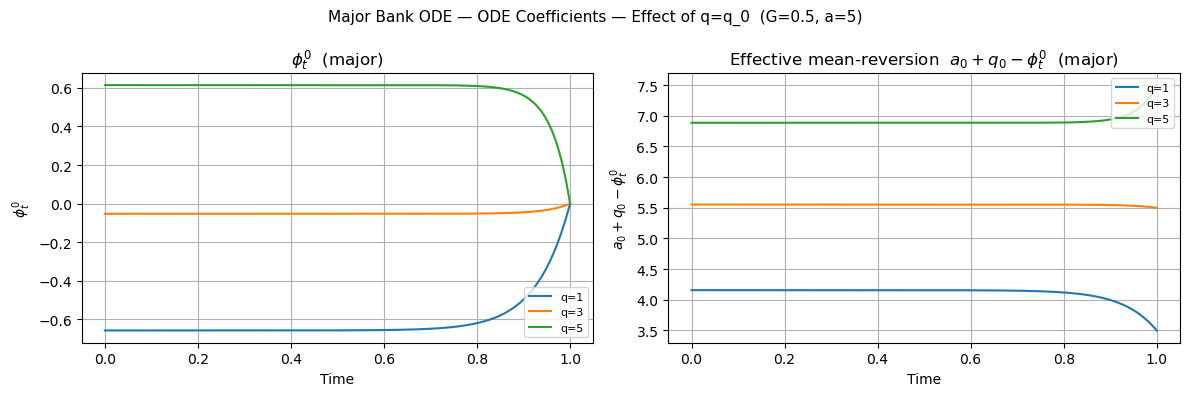

In [12]:
# ── q = q_0 sweep: {1, 3, 5} ─────────────────────────────────────────────────
q_sweep = [1, 3, 5]
labels  = [f'q={v}' for v in q_sweep]
models  = []

fig, axes = plt.subplots(1, len(q_sweep), figsize=(13, 4), sharey=True)
fig.suptitle(f'Trajectories — Effect of q=q_0  (G={G}, a={a}, N={N})', fontsize=11)
for ax, q_val, lbl in zip(axes, q_sweep, labels):
    np.random.seed(42)
    m = MFG(make_config(q_val=q_val)); m.solve_ODE()
    x_bar, x_major, x_minor = m.simulate(N, N_sim, do_plot=False)
    traj_plot(ax, x_bar, x_major, x_minor, m, f'{lbl}  (ε={q_val**2+0.5:.1f})')
    models.append(m)
axes[0].set_ylabel('Log-monetary reserve'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

ode_plot(models, labels, f'ODE Coefficients — Effect of q=q_0  (G={G}, a={a})')

In [ ]:
x_bar